# Hybrid BiTCN-BiGRU-Cross Attention + Semiogram Features
## Analisis Pola Langkah CVA dari Sinyal Accelerometer & Gyroscope IMU

**Judul Penelitian:**
*Analisis Pola Langkah Penderita CVA Menggunakan Sinyal Accelerometer dan Gyroscope dengan Hybrid BiTCN-BiGRU-Cross Attention dan Semiogram Features*

**Referensi Dataset:** Voisard et al. (2025). Scientific Data. https://doi.org/10.1038/s41597-025-05959-w

**Referensi Semiogram:** Voisard et al. (2025). Image Processing On Line. https://doi.org/10.5201/ipol.2025.535

### Arsitektur Pipeline
User input metadata
↓
Sensor HP (ACC + Gyro)
↓
Preprocessing (filtering, segmentation, normalization)
↓
├── Cabang A: Semiogram (20 fitur)
│     ↓
│   ML / MLP
│     ↓
│   z_tabular
│
└── Cabang B: Raw Signal
      ↓
    BiTCN
      ↓
    BiGRU
      ↓
 Cross Attention
      ↓
    z_signal

Fusion (concat z_tabular + z_signal + metadata)
↓
Shared Dense Layer
↓
Multi-task Output:
- FMA-LE (regresi)
- Severity (klasifikasi)
- CVA vs Healthy (probabilitas)



---
## TAHAP 1 -- LOAD DATASET (TIDAK DIUBAH)

### CELL 1.1 -- Import Dasar

In [1]:
import os
import json
import pandas as pd
import numpy as np
import pickle
from collections import defaultdict

In [2]:
import os

# Set paths untuk local dataset
base_path = os.path.abspath('.')
cva_path = os.path.join(base_path, 'CVA')
hs_path = os.path.join(base_path, 'HS')

print(f"Base path: {base_path}")
print(f"CVA path: {cva_path}")
print(f"HS path: {hs_path}")
print(f"CVA folder exists: {os.path.exists(cva_path)}")
print(f"HS folder exists: {os.path.exists(hs_path)}")

Base path: c:\Users\fizel\OneDrive\Documents\Proyek Penelitian_Progress
CVA path: c:\Users\fizel\OneDrive\Documents\Proyek Penelitian_Progress\CVA
HS path: c:\Users\fizel\OneDrive\Documents\Proyek Penelitian_Progress\HS
CVA folder exists: True
HS folder exists: True


In [3]:
# Folder lokal sudah tersedia, tidak perlu extract
# Dataset sudah ada di folder CVA dan HS

# Verifikasi struktur folder
print("=== CVA Folders ===")
if os.path.exists(cva_path):
    cva_folders = sorted([d for d in os.listdir(cva_path) if os.path.isdir(os.path.join(cva_path, d))])
    print(f"Total CVA folders: {len(cva_folders)}")
    print(f"First few: {cva_folders[:5]}")
else:
    print("CVA folder tidak ditemukan!")

print("\n=== HS Folders ===")
if os.path.exists(hs_path):
    hs_folders = sorted([d for d in os.listdir(hs_path) if os.path.isdir(os.path.join(hs_path, d))])
    print(f"Total HS folders: {len(hs_folders)}")
    print(f"First few: {hs_folders[:5]}")
else:
    print("HS folder tidak ditemukan!")

=== CVA Folders ===
Total CVA folders: 49
First few: ['CVA_1', 'CVA_10', 'CVA_11', 'CVA_12', 'CVA_13']

=== HS Folders ===
Total HS folders: 73
First few: ['HS_1', 'HS_10', 'HS_11', 'HS_12', 'HS_13']


In [4]:
import os
import json

# Cari file meta di folder CVA dan HS
meta_files = []

# Cari di CVA
for root, dirs, files in os.walk(cva_path):
    for f in files:
        if f.endswith("_meta.json"):
            meta_files.append(os.path.join(root, f))

# Cari di HS
for root, dirs, files in os.walk(hs_path):
    for f in files:
        if f.endswith("_meta.json"):
            meta_files.append(os.path.join(root, f))

print(f"Total meta files ditemukan: {len(meta_files)}")
for p in meta_files[:5]:
    print(p)

Total meta files ditemukan: 488
c:\Users\fizel\OneDrive\Documents\Proyek Penelitian_Progress\CVA\CVA_1\CVA_1_1\CVA_1_1_meta.json
c:\Users\fizel\OneDrive\Documents\Proyek Penelitian_Progress\CVA\CVA_1\CVA_1_2\CVA_1_2_meta.json
c:\Users\fizel\OneDrive\Documents\Proyek Penelitian_Progress\CVA\CVA_10\CVA_10_1\CVA_10_1_meta.json
c:\Users\fizel\OneDrive\Documents\Proyek Penelitian_Progress\CVA\CVA_10\CVA_10_2\CVA_10_2_meta.json
c:\Users\fizel\OneDrive\Documents\Proyek Penelitian_Progress\CVA\CVA_11\CVA_11_1\CVA_11_1_meta.json


In [5]:
# Tampilkan struktur direktori lokal
print("=== STRUKTUR FOLDER CVA ===")
for root, dirs, files in os.walk(cva_path):
    depth = root.replace(cva_path, '').count(os.sep)
    if depth > 2:  # Batasi kedalaman
        continue
    indent = '  ' * depth
    print(f"{indent}📁 {os.path.basename(root)}/")
    for f in files[:3]:
        print(f"{indent}   📄 {f}")
    if len(files) > 3:
        print(f"{indent}   ... (+{len(files)-3} files)")

print("\n=== STRUKTUR FOLDER HS ===")
for root, dirs, files in os.walk(hs_path):
    depth = root.replace(hs_path, '').count(os.sep)
    if depth > 2:  # Batasi kedalaman
        continue
    indent = '  ' * depth
    print(f"{indent}📁 {os.path.basename(root)}/")
    for f in files[:3]:
        print(f"{indent}   📄 {f}")
    if len(files) > 3:
        print(f"{indent}   ... (+{len(files)-3} files)")

=== STRUKTUR FOLDER CVA ===
📁 CVA/
  📁 CVA_1/
    📁 CVA_1_1/
       📄 CVA_1_1_meta.json
       📄 CVA_1_1_plot.png
       📄 CVA_1_1_processed_data.txt
       ... (+4 files)
    📁 CVA_1_2/
       📄 CVA_1_2_meta.json
       📄 CVA_1_2_plot.png
       📄 CVA_1_2_processed_data.txt
       ... (+4 files)
  📁 CVA_10/
    📁 CVA_10_1/
       📄 CVA_10_1_meta.json
       📄 CVA_10_1_plot.png
       📄 CVA_10_1_processed_data.txt
       ... (+4 files)
    📁 CVA_10_2/
       📄 CVA_10_2_meta.json
       📄 CVA_10_2_plot.png
       📄 CVA_10_2_processed_data.txt
       ... (+4 files)
  📁 CVA_11/
    📁 CVA_11_1/
       📄 CVA_11_1_meta.json
       📄 CVA_11_1_plot.png
       📄 CVA_11_1_processed_data.txt
       ... (+4 files)
    📁 CVA_11_2/
       📄 CVA_11_2_meta.json
       📄 CVA_11_2_plot.png
       📄 CVA_11_2_processed_data.txt
       ... (+4 files)
  📁 CVA_12/
    📁 CVA_12_1/
       📄 CVA_12_1_meta.json
       📄 CVA_12_1_plot.png
       📄 CVA_12_1_processed_data.txt
       ... (+4 files)
    📁 CVA_12_2/


---
## SEC 2 -- Library Imports & Configuration


In [ ]:
# Install required libraries (run once)
%pip install torch torchvision scikit-learn xgboost shap tqdm -q


Note: you may need to restart the kernel to use updated packages.


In [7]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pickle, json, os
from scipy.fft import rfft, rfftfreq
from scipy.signal import welch
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                              accuracy_score, f1_score, confusion_matrix,
                              classification_report, roc_auc_score)
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from tqdm.auto import tqdm

print(f'PyTorch: {torch.__version__}')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')


PyTorch: 2.11.0+cpu
Device : cpu


### SEC 2.1 -- Configuration & Hyperparameters


In [8]:
# ═══════════════════════════════════════════════════
# CONFIGURATION  (edit here to tune)
# ═══════════════════════════════════════════════════
CFG = dict(
    # ── data ────────────────────────────────────────
    FS          = 100,      # sampling frequency (Hz)
    T_MAX       = 400,      # fixed sequence length (samples) ~4s
    N_TS_CHAN   = 6,        # Acc_X/Y/Z + Gyr_X/Y/Z

    # ── labels ──────────────────────────────────────
    # FMA-LE severity thresholds (Fugl-Meyer 2025 clinical guidelines)
    SEV_MILD_MIN    = 25,   # mild   : 25-34
    SEV_MOD_MIN     = 14,   # moderate: 14-24
    # severe: 0-13  (index 0), moderate: index 1, mild: index 2

    # ── model ───────────────────────────────────────
    HIDDEN      = 64,
    N_TCN_LAYERS= 4,
    TCN_KERNEL  = 3,
    N_GRU_LAYERS= 1,
    N_HEADS     = 4,
    N_META      = 6,        # metadata features: age,bmi,tug,vga,laterality,deficit_side
    N_SEMI      = 17,       # semiogram features
    DROPOUT     = 0.35,

    # ── loss weights ────────────────────────────────
    ALPHA       = 1.0,      # regression MSE weight
    BETA        = 0.5,      # severity CE weight
    GAMMA       = 0.5,      # CVA/HS CE weight

    # ── training ────────────────────────────────────
    N_SPLITS    = 5,        # GroupKFold folds
    EPOCHS      = 80,
    BATCH       = 32,
    LR          = 1e-3,
    WEIGHT_DECAY= 1e-4,
    PATIENCE    = 15,       # early stopping patience
    SEED        = 42,
)

# ── reproducibility ─────────────────────────────────
import random
random.seed(CFG['SEED'])
np.random.seed(CFG['SEED'])
torch.manual_seed(CFG['SEED'])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(CFG['SEED'])

print('Configuration loaded.')
print(f'T_MAX={CFG["T_MAX"]}  HIDDEN={CFG["HIDDEN"]}  FOLDS={CFG["N_SPLITS"]}')


Configuration loaded.
T_MAX=400  HIDDEN=64  FOLDS=5


---
## SEC 3 -- Data Loading & Feature Extraction

Lanjutan dari `meta_files` yang sudah tersedia (Tahap 1).  
Setiap trial di-parse untuk menghasilkan:
- **Time-series IMU**: dari `_processed_data.txt` (LB sensor, 6 channel)
- **Semiogram features**: 17 parameter gait deterministik (Voisard 2025)
- **Metadata**: age, BMI, TUG, VGA, laterality, deficit side
- **Labels**: FMA-LE (regression), severity (3-class), CVA/HS (binary)


### SEC 3.1 -- Semiogram Feature Functions


In [13]:
FS = CFG['FS']

def remove_outliers(v, zlim=2.0):
    v = np.asarray(v, dtype=float)
    if len(v) < 3: return v
    sd = np.std(v)
    if sd < 1e-9: return v
    return v[np.abs((v - np.mean(v)) / sd) <= zlim]

def sparc_gyr(gyr_norm, fs=FS, padlevel=4, fc=10.0, amp_th=0.05):
    n = len(gyr_norm)
    if n < 20: return np.nan
    nfft = int(2 ** (np.ceil(np.log2(n)) + padlevel))
    Mf   = np.abs(rfft(gyr_norm, n=nfft))
    freq = rfftfreq(nfft, d=1.0/fs)
    mx   = Mf.max()
    if mx < 1e-9: return np.nan
    Mf_n = Mf / mx
    idx  = (freq <= fc) & (Mf_n >= amp_th)
    if idx.sum() < 2: return np.nan
    fn = (freq[idx] - freq[idx][0]) / (freq[idx][-1] - freq[idx][0] + 1e-9)
    return float(-np.sum(np.sqrt(np.diff(fn)**2 + np.diff(Mf_n[idx])**2)))

def ldlj_acc(acc_mag, fs=FS):
    M = len(acc_mag)
    if M < 10: return np.nan
    mx = acc_mag.max()
    if mx < 1e-6: return np.nan
    s = M / (fs * mx**2)
    j = np.diff(acc_mag) * fs
    return float(-np.log(abs(s / fs * np.sum(j**2)) + 1e-12))

def autocorr_fft(x):
    x = np.asarray(x, float)
    if len(x) == 0:
        return np.zeros(1)  # Return a default zero array if input is empty

    xc = x - x.mean()
    f  = rfft(xc, n=2*len(xc))
    ac = np.real(np.fft.irfft(f * np.conj(f)))[:len(xc)]
    d  = ac[0]
    return ac / d if d > 1e-9 else np.zeros(len(xc))

def improved_hr(sig, hs_list, axis='AP'):
    ihrs = []
    for k in range(1, len(hs_list)-1):
        h0, h1 = hs_list[k], hs_list[k+1]
        if h1 <= h0 or h1 > len(sig): continue
        seg = sig[h0:h1]
        if len(seg) < 10: continue
        Mf = np.abs(rfft(seg))
        nh = min(10, len(Mf)//2)
        if nh < 2: continue
        even = sum(Mf[2*j]**2 for j in range(1, nh+1) if 2*j < len(Mf))
        odd  = sum(Mf[2*j-1]**2 for j in range(1, nh+1) if 2*j-1 < len(Mf))
        tot  = even + odd
        if tot < 1e-9: continue
        ihrs.append(100*even/tot if axis in ('AP','CC') else 100*odd/tot)
    return float(np.mean(ihrs)) if ihrs else np.nan

print('Semiogram helper functions ready.')


Semiogram helper functions ready.


### SEC 3.2 -- Semiogram Computation per Trial


In [16]:
def compute_semiogram(meta, sig6):
    # sig6: (T, 6) array [accX, accY, accZ, gyrX, gyrY, gyrZ] or None
    ev_L  = meta.get('leftGaitEvents',  [])
    ev_R  = meta.get('rightGaitEvents', [])
    utb   = meta.get('uturnBoundaries', None)

    hs_L = sorted([int(e[1]) for e in ev_L if len(e)>=2])
    hs_R = sorted([int(e[1]) for e in ev_R if len(e)>=2])
    to_L = sorted([int(e[0]) for e in ev_L if len(e)>=2])
    to_R = sorted([int(e[0]) for e in ev_R if len(e)>=2])

    # U-turn time
    UtrT = float(utb[1]-utb[0])/FS if utb and len(utb)>=2 else np.nan
    u_st = int(utb[0]) if utb else 0
    u_en = int(utb[1]) if utb else 0

    # Stride durations
    stL = remove_outliers(np.diff(hs_L)/FS) if len(hs_L)>1 else np.array([])
    stR = remove_outliers(np.diff(hs_R)/FS) if len(hs_R)>1 else np.array([])
    st  = np.concatenate([stL, stR])
    st  = st[(st>0.5)&(st<3.0)] if len(st) else st

    StrT   = float(np.mean(st))  if len(st)>0 else np.nan
    CVStrT = float(np.std(st)/(np.mean(st)+1e-9)*100) if len(st)>1 else np.nan

    # Double stance
    dsl = []
    for i in range(len(hs_R)-1):
        dur = hs_R[i+1]-hs_R[i]
        if dur < 1: continue
        js = [j for j,h in enumerate(hs_L) if hs_R[i]<h<hs_R[i+1]]
        if not js: continue
        j = js[0]
        if j < len(to_L) and i < len(to_R):
            d = ((hs_R[i+1]-to_L[j])+(to_R[i]-hs_R[i]))/dur
            if 0<d<1: dsl.append(d)
    ds  = remove_outliers(np.array(dsl)) if dsl else np.array([])
    dstT   = float(np.mean(ds)*100) if len(ds)>0 else np.nan
    CVdstT = float(np.std(ds)/(np.mean(ds)+1e-9)*100) if len(ds)>1 else np.nan

    # Velocity, step length
    all_hs = sorted(hs_L+hs_R)
    if len(all_hs)>=2:
        wd = (max(all_hs)-min(all_hs))/FS
        if u_en>u_st: wd -= (u_en-u_st)/FS
        wd = max(wd, 0.1)
        V    = float(10.0/wd)
        SteL = float(20.0/max(len(hs_L)+len(hs_R),1))
    else:
        V = SteL = np.nan

    # Swing ratio
    swL = remove_outliers(np.array([(hs_L[i]-to_L[i])/FS
                                     for i in range(min(len(hs_L),len(to_L)))
                                     if hs_L[i]>to_L[i]]))
    swR = remove_outliers(np.array([(hs_R[i]-to_R[i])/FS
                                     for i in range(min(len(hs_R),len(to_R)))
                                     if hs_R[i]>to_R[i]]))
    swlm = float(np.mean(swL)) if len(swL) else np.nan
    swrm = float(np.mean(swR)) if len(swR) else np.nan
    swTr = float(min(swlm,swrm)/max(swlm,swrm)) \
           if (not np.isnan(swlm) and not np.isnan(swrm) and max(swlm,swrm)>0) else np.nan

    # TUG
    TUG = meta.get('TUG', np.nan)
    try: TUG = float(TUG) if TUG is not None else np.nan
    except: TUG = np.nan

    # Signal features
    RMSaML=SPARCrot=LDLJ=P1aCC=P2aCC=P1P2aCC=iHRaAP=iHRaML=iHRaCC=np.nan

    if sig6 is not None:
        accX=sig6[:,0]; accY=sig6[:,1]; accZ=sig6[:,2]
        gyrX=sig6[:,3]; gyrY=sig6[:,4]; gyrZ=sig6[:,5]

        t0 = max(0, min(all_hs)-50) if all_hs else 0
        t1 = min(sig6.shape[0]-1, max(all_hs)+50) if all_hs else sig6.shape[0]-1

        if u_en>u_st+20:
            go_s   = slice(t0, u_st)
            back_s = slice(u_en, t1)
        else:
            go_s = back_s = slice(t0, t1)

        rms_go   = float(np.sqrt(np.mean(accY[go_s]**2)))
        rms_back = float(np.sqrt(np.mean(accY[back_s]**2)))
        RMSaML   = float(min(rms_go, rms_back))

        gn = np.sqrt(gyrX[t0:t1]**2+gyrY[t0:t1]**2+gyrZ[t0:t1]**2)
        SPARCrot = sparc_gyr(gn)

        amG = np.sqrt(accX[go_s]**2+accY[go_s]**2+accZ[go_s]**2)
        amB = np.sqrt(accX[back_s]**2+accY[back_s]**2+accZ[back_s]**2)
        ld_go   = ldlj_acc(amG)
        ld_back = ldlj_acc(amB)
        if not np.isnan(ld_go) and not np.isnan(ld_back):
            LDLJ = float(0.5*(ld_go+ld_back))
        elif not np.isnan(ld_go): LDLJ = ld_go

        if not np.isnan(StrT) and StrT>0:
            ac = autocorr_fft(accX[t0:t1])
            nac = len(ac)
            p1lo=int(StrT/3*FS); p1hi=int(2*StrT/3*FS)
            p2lo=int(5*StrT/6*FS); p2hi=int(7*StrT/6*FS)
            if p1hi < nac: P1aCC = float(ac[p1lo:p1hi].max())
            if p2hi < nac: P2aCC = float(ac[p2lo:p2hi].max())
            if not np.isnan(P1aCC) and not np.isnan(P2aCC) and P2aCC>1e-6:
                P1P2aCC = float(1 - min(abs(1-P1aCC/P2aCC), 1))

        hs_all = sorted(hs_L+hs_R)
        hs_in  = [h for h in hs_all if t0<=h<=t1]
        if len(hs_in)>=4:
            iHRaAP = improved_hr(accX, hs_in, 'AP')
            iHRaML = improved_hr(accY, hs_in, 'ML')
            iHRaCC = improved_hr(accZ, hs_in, 'CC')

    return dict(V=V, SteL=SteL, UtrT=UtrT, StrT=StrT, CVStrT=CVStrT,
                dstT=dstT, CVdstT=CVdstT, swTr=swTr,
                RMSaML=RMSaML, SPARCrot=SPARCrot, LDLJ=LDLJ,
                P1aCC=P1aCC, P2aCC=P2aCC, P1P2aCC=P1P2aCC,
                iHRaAP=iHRaAP, iHRaML=iHRaML, iHRaCC=iHRaCC,
                TUG=TUG)

SEMI_COLS = ['V','SteL','UtrT','StrT','CVStrT','dstT','CVdstT','swTr',
             'RMSaML','SPARCrot','LDLJ','P1aCC','P2aCC','P1P2aCC',
             'iHRaAP','iHRaML','iHRaCC','TUG']

print(f'Semiogram: {len(SEMI_COLS)} features')


Semiogram: 18 features


### SEC 3.3 -- Time-Series Loader


In [17]:
ACC_PRIO = [
    ['LB_FreeAcc_X','LB_FreeAcc_Y','LB_FreeAcc_Z'],
    ['LB_Acc_X','LB_Acc_Y','LB_Acc_Z'],
]
GYR_CANDS = ['LB_Gyr_X','LB_Gyr_Y','LB_Gyr_Z']

def _find_cols(df_cols, cands_list):
    lc = [c.lower() for c in df_cols]
    for cands in cands_list:
        found = []
        for c in cands:
            m = [df_cols[i] for i,x in enumerate(lc) if c.lower() in x]
            if m: found.append(m[0])
        if len(found)==3: return found
    return None

def load_ts(trial_dir, t_max):
    pf = None
    for fn in os.listdir(trial_dir):
        if 'processed' in fn.lower() and fn.endswith('.txt'):
            pf = os.path.join(trial_dir, fn); break
    if pf is None: return None

    df = None
    for sep in ['\t',' ',',']:
        try:
            tmp = pd.read_csv(pf, sep=sep, engine='python')
            if tmp.shape[1]>=6: df=tmp; break
        except: continue
    if df is None: return None

    dc = list(df.columns)
    ac = _find_cols(dc, ACC_PRIO)
    lc = [c.lower() for c in dc]
    gc = [dc[i] for gc_ in GYR_CANDS
          for i,x in enumerate(lc) if gc_.lower() in x]
    gc = list(dict.fromkeys(gc))[:3]   # unique, preserve order
    if ac is None or len(gc)<3: return None

    try:
        sig = np.hstack([df[ac].values.astype(float),
                         df[gc].values.astype(float)])   # (T_raw, 6)
    except: return None

    # Interpolate NaN
    for ch in range(6):
        nans = np.isnan(sig[:,ch])
        if nans.any() and (~nans).any():
            sig[nans,ch] = np.interp(
                np.where(nans)[0], np.where(~nans)[0], sig[~nans,ch])
    sig = np.nan_to_num(sig, nan=0.0)

    T = sig.shape[0]
    if T >= t_max:
        return sig[:t_max].astype(np.float32)
    pad = np.zeros((t_max-T, 6), dtype=np.float32)
    return np.vstack([sig, pad]).astype(np.float32)

print('Time-series loader ready.')


Time-series loader ready.


### SEC 3.4 -- Parse All Trials from meta_files


In [19]:
# SEC 3.4 -- Parse all trials from meta_files
# Variables inherited from Tahap 1: meta_files, cva_path, hs_path

def fmale_to_severity(score):
    # 0=severe (0-13), 1=moderate (14-24), 2=mild (25-34)
    if np.isnan(score): return -1
    if score < CFG['SEV_MOD_MIN']:  return 0   # severe
    if score < CFG['SEV_MILD_MIN']: return 1   # moderate
    return 2                                    # mild

# ✅ SAFE FLOAT (biar ga error kayak "Not evaluated")
def safe_float(x, default=0.0):
    if x is None:
        return default
    if isinstance(x, str):
        x = x.strip().lower()
        if x in ["", "not evaluated", "not available", "na", "n/a", "nan", "none", "-"]:
            return default
    try:
        return float(x)
    except (ValueError, TypeError):
        return default


records = []
t_max   = CFG['T_MAX']

print(f'Processing {len(meta_files)} trials...')

for mpath in tqdm(meta_files, desc='Loading'):
    try:
        with open(mpath) as f:
            meta = json.load(f)
    except:
        continue

    fname   = os.path.basename(mpath).replace('_meta.json','')
    parts   = fname.split('_')
    if len(parts) < 3:
        continue

    subj_id = '_'.join(parts[:-1])

    try:
        trial_id = int(parts[-1])
    except:
        continue

    trial_dir = os.path.dirname(mpath)
    cohort    = 'CVA' if 'CVA' in subj_id.upper() else 'HS'
    label_bin = 1 if cohort == 'CVA' else 0

    # FMA-LE
    fma_raw = meta.get('evaluationScoreValue', np.nan)
    try:
        fma = float(fma_raw) if fma_raw is not None else np.nan
    except:
        fma = np.nan

    if cohort == 'HS':
        fma = np.nan

    severity = fmale_to_severity(fma)

    # ✅ Metadata features (SAFE VERSION)
    age = safe_float(meta.get('age'), 0.0)
    bmi = safe_float(meta.get('BMI'), 0.0)
    tug = safe_float(meta.get('TUG'), 0.0)
    vga = safe_float(meta.get('visualGaitEvaluation'), 0.0)

    lat   = 1.0 if str(meta.get('laterality','')).lower() == 'right' else 0.0
    def_s = 1.0 if str(meta.get('clinicalDeficitSide','')).lower() == 'right' else 0.0

    meta_vec = np.array([age, bmi, tug, vga, lat, def_s], dtype=np.float32)

    # Time-series
    sig6 = load_ts(trial_dir, t_max)   # (T_MAX,6) or None
    if sig6 is None:
        sig6 = np.zeros((t_max, 6), dtype=np.float32)
        ts_valid = False
    else:
        ts_valid = True

    # Semiogram
    semi_d = compute_semiogram(meta, sig6 if ts_valid else None)
    semi_v = np.array([semi_d.get(k, np.nan) for k in SEMI_COLS], dtype=np.float32)

    records.append(dict(
        subj_id   = subj_id,
        trial_id  = trial_id,
        cohort    = cohort,
        label_bin = label_bin,
        fma_le    = fma,
        severity  = severity,
        ts        = sig6,
        semi      = semi_v,
        meta_vec  = meta_vec,
        ts_valid  = ts_valid,
    ))

print(f'\nLoaded {len(records)} trials')

cohort_cnt = {c: sum(1 for r in records if r['cohort']==c) for c in ('CVA','HS')}
print(f'CVA: {cohort_cnt["CVA"]}   HS: {cohort_cnt["HS"]}')

cva_recs = [r for r in records if r['cohort']=='CVA' and not np.isnan(r['fma_le'])]
print(f'CVA with FMA-LE: {len(cva_recs)}')

if len(cva_recs) > 0:
    fmas = np.array([r['fma_le'] for r in cva_recs])
    print(f'FMA-LE range: {fmas.min():.0f} - {fmas.max():.0f}  mean={fmas.mean():.1f}')
else:
    print("No valid FMA-LE data found.")

Processing 488 trials...


Loading: 100%|██████████| 488/488 [00:55<00:00,  8.84it/s]


Loaded 488 trials
CVA: 128   HS: 360
CVA with FMA-LE: 128
FMA-LE range: 7 - 34  mean=26.4


### SEC 3.5 -- Dataset Overview Visualization


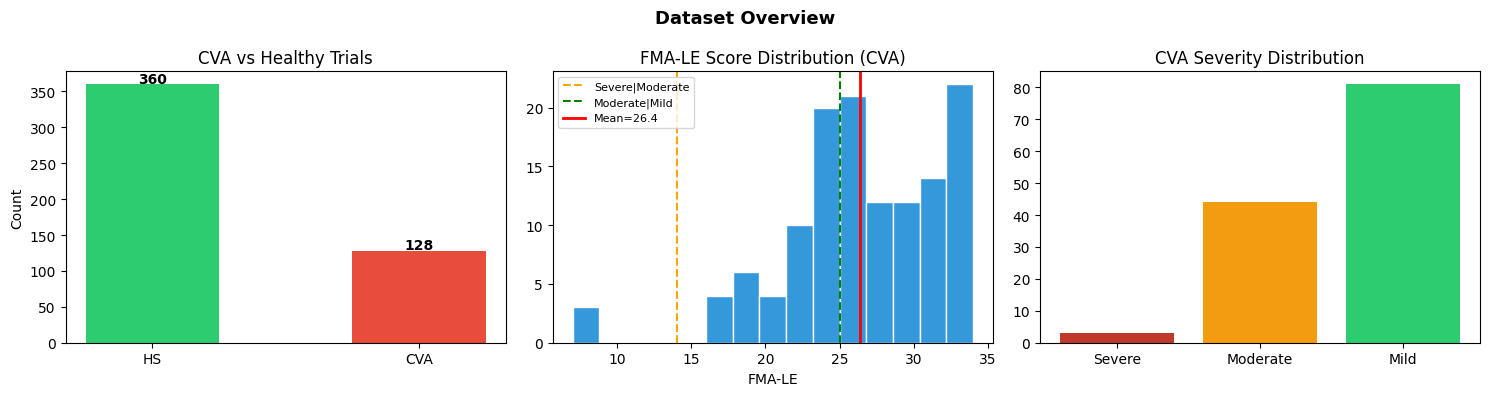

Saved -> dataset_overview.png


In [20]:
fig, axes = plt.subplots(1,3, figsize=(15,4))
fig.suptitle('Dataset Overview', fontsize=13, fontweight='bold')

# 1. Label distribution
ax=axes[0]
lbls=['HS','CVA']
cnts=[cohort_cnt['HS'],cohort_cnt['CVA']]
bars=ax.bar(lbls, cnts, color=['#2ecc71','#e74c3c'], width=0.5)
for b,c in zip(bars,cnts): ax.text(b.get_x()+0.25,c+2,str(c),ha='center',fontweight='bold')
ax.set_title('CVA vs Healthy Trials'); ax.set_ylabel('Count')

# 2. FMA-LE distribution
ax=axes[1]
ax.hist(fmas, bins=15, color='#3498db', edgecolor='white')
ax.axvline(CFG['SEV_MOD_MIN'],  color='orange', ls='--', label='Severe|Moderate')
ax.axvline(CFG['SEV_MILD_MIN'], color='green',  ls='--', label='Moderate|Mild')
ax.axvline(fmas.mean(), color='red', ls='-', lw=2, label=f'Mean={fmas.mean():.1f}')
ax.set_title('FMA-LE Score Distribution (CVA)'); ax.set_xlabel('FMA-LE'); ax.legend(fontsize=8)

# 3. Severity class
ax=axes[2]
sev_lbl=['Severe','Moderate','Mild']
sev_cnt=[sum(1 for r in cva_recs if r['severity']==i) for i in range(3)]
ax.bar(sev_lbl, sev_cnt, color=['#c0392b','#f39c12','#2ecc71'])
ax.set_title('CVA Severity Distribution')

plt.tight_layout()
plt.savefig('dataset_overview.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved -> dataset_overview.png')


---
## SEC 4 -- Subject-Wise Split (GroupKFold)

**Why GroupKFold?**  
One subject can have 2-16 trials. A random split would leak subject-level gait patterns.
GroupKFold ensures all trials from one subject stay in a single fold.

The **held-out test set** (fold 0 validation) is fixed across all experiments
to allow fair comparison.


In [21]:
# Arrays for GroupKFold
all_subj = np.array([r['subj_id']   for r in records])
all_y    = np.array([r['label_bin'] for r in records])
all_idx  = np.arange(len(records))

gkf = GroupKFold(n_splits=CFG['N_SPLITS'])

folds = list(gkf.split(all_idx, all_y, groups=all_subj))

# Use fold 0 as the final held-out test set
_, test_idx  = folds[0]
train_val_mask = np.ones(len(records), dtype=bool)
train_val_mask[test_idx] = False
trainval_idx = np.where(train_val_mask)[0]

print(f'Total trials      : {len(records)}')
print(f'Test  (fold-0)    : {len(test_idx)}')
print(f'Train+Val         : {len(trainval_idx)}')

# Cross-validation folds on trainval_idx
subj_tv = all_subj[trainval_idx]
y_tv    = all_y[trainval_idx]
inner_folds = list(GroupKFold(n_splits=CFG['N_SPLITS']).split(
    trainval_idx, y_tv, groups=subj_tv))

print(f'Inner CV folds    : {len(inner_folds)}')
for fi,(tri,vai) in enumerate(inner_folds[:3]):
    print(f'  Fold {fi}: train={len(tri)} val={len(vai)}')


Total trials      : 488
Test  (fold-0)    : 97
Train+Val         : 391
Inner CV folds    : 5
  Fold 0: train=312 val=79
  Fold 1: train=312 val=79
  Fold 2: train=313 val=78


---
## SEC 5 -- Dataset & DataLoader

The custom `GaitDataset` returns a dict with:
- `ts`: time-series tensor `(T, C)`
- `semi`: semiogram tensor `(17,)`
- `meta`: metadata tensor `(6,)`
- `fma_le`: regression target (NaN masked to -1 for HS)
- `severity`: 3-class label (-1 for HS)
- `label_bin`: binary CVA/HS label
- `is_cva`: float mask for CVA-only losses


In [22]:
class GaitDataset(Dataset):
    def __init__(self, rec_list, ts_scaler=None, semi_imp=None, semi_scl=None,
                 meta_imp=None, meta_scl=None, fit=False):
        self.recs = rec_list

        ts_all   = np.stack([r['ts']       for r in rec_list], 0)  # (N,T,6)
        semi_all = np.stack([r['semi']      for r in rec_list], 0)  # (N,F)
        meta_all = np.stack([r['meta_vec']  for r in rec_list], 0)  # (N,6)

        # Per-channel scaling for time-series
        N,T,C = ts_all.shape
        ts_flat = ts_all.reshape(-1,C)
        if fit:
            self.ts_scaler = StandardScaler().fit(ts_flat)
        else:
            self.ts_scaler = ts_scaler
        ts_flat_sc = self.ts_scaler.transform(ts_flat)
        self.ts = ts_flat_sc.reshape(N,T,C).astype(np.float32)

        # Semiogram
        if fit:
            self.semi_imp = SimpleImputer(strategy='median').fit(semi_all)
            self.semi_scl = StandardScaler().fit(self.semi_imp.transform(semi_all))
        else:
            self.semi_imp = semi_imp; self.semi_scl = semi_scl
        self.semi = self.semi_scl.transform(
            self.semi_imp.transform(semi_all)).astype(np.float32)

        # Metadata
        if fit:
            self.meta_imp = SimpleImputer(strategy='median').fit(meta_all)
            self.meta_scl = StandardScaler().fit(self.meta_imp.transform(meta_all))
        else:
            self.meta_imp = meta_imp; self.meta_scl = meta_scl
        self.meta_arr = self.meta_scl.transform(
            self.meta_imp.transform(meta_all)).astype(np.float32)

        # Labels
        self.fma_le    = np.array([r['fma_le']   for r in rec_list], dtype=np.float32)
        self.severity  = np.array([r['severity']  for r in rec_list], dtype=np.int64)
        self.label_bin = np.array([r['label_bin'] for r in rec_list], dtype=np.int64)
        self.is_cva    = np.array([1.0 if r['cohort']=='CVA' and not np.isnan(r['fma_le'])
                                   else 0.0 for r in rec_list], dtype=np.float32)

        # Replace NaN FMA-LE with -1 (masked in loss)
        self.fma_le    = np.nan_to_num(self.fma_le, nan=-1.0)
        # Replace severity -1 (HS) with 0 for tensor (masked in loss)
        self.severity  = np.clip(self.severity, 0, 2)

    def __len__(self): return len(self.recs)

    def __getitem__(self, idx):
        return dict(
            ts        = torch.FloatTensor(self.ts[idx]),
            semi      = torch.FloatTensor(self.semi[idx]),
            meta      = torch.FloatTensor(self.meta_arr[idx]),
            fma_le    = torch.FloatTensor([self.fma_le[idx]]),
            severity  = torch.LongTensor([self.severity[idx]]),
            label_bin = torch.LongTensor([self.label_bin[idx]]),
            is_cva    = torch.FloatTensor([self.is_cva[idx]]),
        )

print('GaitDataset class defined.')


GaitDataset class defined.


---
## SEC 6 -- Model Architecture

```
Input TS (B,T,6)          Semiogram (B,17)       Metadata (B,6)
    |                          |                      |
  split Acc|Gyr              MLP                     |
    |         |                |                      |
 BiTCN     BiTCN           z_semi (B,32)            |
    |         |                                       |
 BiGRU     BiGRU                                     |
    |         |                                       |
 CrossAttn (Acc x Gyr)                              |
    |                                                 |
 z_signal (B, 2*HIDDEN)                             |
    |                                                 |
    +---------+------concat--------+-----------------+
                                   |
                         Shared Dense FC
                                   |
              +--------------------+--------------------+
              |                    |                    |
        Reg Head             Sev Head           CVA/HS Head
        (FMA-LE)          (3-class CE)         (2-class CE)
```


### SEC 6.1 -- BiTCN Block


In [23]:
class TCNBlock(nn.Module):
    # Bidirectional dilated temporal conv residual block
    def __init__(self, in_ch, out_ch, kernel=3, dilation=1, dropout=0.2):
        super().__init__()
        pad = (kernel-1)*dilation
        self.fwd = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel, padding=pad, dilation=dilation),
            nn.BatchNorm1d(out_ch), nn.GELU(), nn.Dropout(dropout))
        self.bwd = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel, padding=pad, dilation=dilation),
            nn.BatchNorm1d(out_ch), nn.GELU(), nn.Dropout(dropout))
        self.fuse = nn.Conv1d(out_ch*2, out_ch, 1)
        self.skip = nn.Conv1d(in_ch, out_ch, 1) if in_ch!=out_ch else nn.Identity()

    def forward(self, x):              # x: (B,C,T)
        T = x.size(2)
        fwd = self.fwd(x)[:,:,:T]
        bwd = torch.flip(self.bwd(torch.flip(x,[2]))[:,:,:T],[2])
        return F.gelu(self.fuse(torch.cat([fwd,bwd],1)) + self.skip(x))


class BiTCN(nn.Module):
    def __init__(self, in_ch, hidden, n_layers, kernel=3, dropout=0.2):
        super().__init__()
        layers, ch = [], in_ch
        for i in range(n_layers):
            layers.append(TCNBlock(ch, hidden, kernel, dilation=2**i, dropout=dropout))
            ch = hidden
        self.net = nn.Sequential(*layers)

    def forward(self, x):   # x: (B,T,C) -> (B,T,hidden)
        return self.net(x.permute(0,2,1)).permute(0,2,1)

print('BiTCN defined.')


BiTCN defined.


### SEC 6.2 -- Full Hybrid Multi-Task Model


In [24]:
class HybridMultiTaskModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        H  = cfg['HIDDEN']
        NL = cfg['N_TCN_LAYERS']
        KS = cfg['TCN_KERNEL']
        DR = cfg['DROPOUT']
        NH = cfg['N_HEADS']
        NS = cfg['N_SEMI']
        NM = cfg['N_META']

        # ── Semiogram MLP branch ────────────────────────
        self.semi_mlp = nn.Sequential(
            nn.Linear(NS, H), nn.LayerNorm(H), nn.GELU(), nn.Dropout(DR),
            nn.Linear(H, H//2), nn.LayerNorm(H//2), nn.GELU(),
        )

        # ── Time-series: Acc stream ──────────────────────
        self.tcn_acc = BiTCN(3, H, NL, KS, DR)
        self.gru_acc = nn.GRU(H, H, batch_first=True, bidirectional=True)

        # ── Time-series: Gyr stream ──────────────────────
        self.tcn_gyr = BiTCN(3, H, NL, KS, DR)
        self.gru_gyr = nn.GRU(H, H, batch_first=True, bidirectional=True)

        # ── Cross Attention: Acc (Q) x Gyr (K,V) ─────────
        d_model = H*2   # bidirectional GRU output
        self.cross_attn = nn.MultiheadAttention(
            d_model, NH, dropout=DR, batch_first=True)
        self.attn_norm  = nn.LayerNorm(d_model)

        # ── Metadata projection ──────────────────────────
        self.meta_proj = nn.Sequential(
            nn.Linear(NM, H//4), nn.ReLU())

        # ── Fusion ────────────────────────────────────────
        # input dim = 2*d_model (acc+gyr) + H//2 (semi) + H//2 (for gyr pool) + H//4 (meta)
        # acc: d_model, gyr: d_model, semi: H//2, meta: H//4
        fusion_in = d_model + d_model + H//2 + H//4
        self.shared_fc = nn.Sequential(
            nn.Linear(fusion_in, H*2), nn.LayerNorm(H*2), nn.GELU(), nn.Dropout(DR),
            nn.Linear(H*2, H),        nn.GELU(), nn.Dropout(DR),
        )

        # ── Multi-task heads ─────────────────────────────
        self.head_reg = nn.Sequential(
            nn.Linear(H, H//2), nn.ReLU(), nn.Linear(H//2, 1))  # FMA-LE
        self.head_sev = nn.Sequential(
            nn.Linear(H, H//2), nn.ReLU(), nn.Linear(H//2, 3))  # severity 3-class
        self.head_cva = nn.Sequential(
            nn.Linear(H, H//2), nn.ReLU(), nn.Linear(H//2, 2))  # CVA/HS 2-class

        self._attn_w = None   # store attention weights

    def forward(self, ts, semi, meta):
        # ts: (B,T,6)  semi: (B,NS)  meta: (B,NM)
        acc = ts[:,:,:3];  gyr = ts[:,:,3:]

        # Acc stream
        acc_h = self.tcn_acc(acc)
        acc_g, _ = self.gru_acc(acc_h)    # (B,T,2H)

        # Gyr stream
        gyr_h = self.tcn_gyr(gyr)
        gyr_g, _ = self.gru_gyr(gyr_h)    # (B,T,2H)

        # Cross-attention
        attn_out, attn_w = self.cross_attn(acc_g, gyr_g, gyr_g)
        self._attn_w = attn_w.detach()
        acc_out = self.attn_norm(acc_g + attn_out)

        # Global avg pool
        z_acc  = acc_out.mean(1)   # (B, 2H)
        z_gyr  = gyr_g.mean(1)    # (B, 2H)

        # Semiogram + metadata
        z_semi = self.semi_mlp(semi)   # (B, H//2)
        z_meta = self.meta_proj(meta)  # (B, H//4)

        z = torch.cat([z_acc, z_gyr, z_semi, z_meta], dim=1)
        shared = self.shared_fc(z)

        out_reg = self.head_reg(shared)   # (B,1)  FMA-LE
        out_sev = self.head_sev(shared)   # (B,3)  severity logits
        out_cva = self.head_cva(shared)   # (B,2)  CVA/HS logits

        return out_reg, out_sev, out_cva


# Quick test
cfg_test = dict(CFG)
cfg_test['N_SEMI'] = len(SEMI_COLS)
m = HybridMultiTaskModel(cfg_test)
total_p = sum(p.numel() for p in m.parameters())
print(f'Model parameters: {total_p:,}')
# Dummy forward
r1,r2,r3 = m(torch.zeros(4,CFG['T_MAX'],6),
              torch.zeros(4,len(SEMI_COLS)),
              torch.zeros(4,CFG['N_META']))
print(f'reg={tuple(r1.shape)}  sev={tuple(r2.shape)}  cva={tuple(r3.shape)}')
del m


Model parameters: 443,126
reg=(4, 1)  sev=(4, 3)  cva=(4, 2)


---
## SEC 7 -- Training Utilities

### Loss Design

```
L_total = alpha * L_reg + beta * L_severity + gamma * L_cva
```

- **L_reg (MSE)**: computed only on CVA samples with valid FMA-LE (masked by `is_cva`)
- **L_severity (CE)**: computed only on CVA samples
- **L_cva (CE)**: computed on all samples


In [25]:
class MultiTaskLoss(nn.Module):
    def __init__(self, alpha=1.0, beta=0.5, gamma=0.5):
        super().__init__()
        self.alpha = alpha
        self.beta  = beta
        self.gamma = gamma
        self.mse   = nn.MSELoss(reduction='none')
        self.ce    = nn.CrossEntropyLoss(reduction='none')

    def forward(self, out_reg, out_sev, out_cva, batch):
        is_cva  = batch['is_cva'].squeeze(1).to(out_reg.device)   # (B,)
        fma_tgt = batch['fma_le'].to(out_reg.device)              # (B,1)
        sev_tgt = batch['severity'].squeeze(1).to(out_sev.device) # (B,)
        cva_tgt = batch['label_bin'].squeeze(1).to(out_cva.device)# (B,)

        # Regression loss (CVA only)
        l_reg_all = self.mse(out_reg.squeeze(1), fma_tgt.squeeze(1))  # (B,)
        n_cva = is_cva.sum().clamp(min=1)
        l_reg = (l_reg_all * is_cva).sum() / n_cva

        # Severity loss (CVA only)
        l_sev_all = self.ce(out_sev, sev_tgt)   # (B,)
        l_sev = (l_sev_all * is_cva).sum() / n_cva

        # CVA/HS classification loss (all)
        l_cva = self.ce(out_cva, cva_tgt).mean()

        total = self.alpha*l_reg + self.beta*l_sev + self.gamma*l_cva
        return total, l_reg.item(), l_sev.item(), l_cva.item()


class EarlyStopping:
    def __init__(self, patience=15, min_delta=1e-4):
        self.patience   = patience
        self.min_delta  = min_delta
        self.best       = float('inf')
        self.counter    = 0
        self.best_state = None

    def __call__(self, val_loss, model):
        if val_loss < self.best - self.min_delta:
            self.best       = val_loss
            self.counter    = 0
            self.best_state = {k: v.cpu().clone() for k,v in model.state_dict().items()}
            return False
        self.counter += 1
        return self.counter >= self.patience

    def restore(self, model):
        if self.best_state:
            model.load_state_dict(self.best_state)

print('Training utilities ready.')


Training utilities ready.


---
## SEC 8 -- Training Loop (GroupKFold)


In [26]:
def make_loaders(tr_recs, va_recs, batch, fit=True,
                  ts_sc=None, semi_imp=None, semi_sc=None,
                  meta_imp=None, meta_sc=None):
    tr_ds = GaitDataset(tr_recs, fit=fit,
                        ts_scaler=ts_sc, semi_imp=semi_imp, semi_scl=semi_sc,
                        meta_imp=meta_imp, meta_scl=meta_sc)
    va_ds = GaitDataset(va_recs, fit=False,
                        ts_scaler=tr_ds.ts_scaler,
                        semi_imp=tr_ds.semi_imp, semi_scl=tr_ds.semi_scl,
                        meta_imp=tr_ds.meta_imp, meta_scl=tr_ds.meta_scl)

    # WeightedRandomSampler to handle CVA/HS imbalance
    lbl = [r['label_bin'] for r in tr_recs]
    n1  = sum(lbl); n0 = len(lbl)-n1
    wts = [len(lbl)/(2*max(n1,1)) if l==1
           else len(lbl)/(2*max(n0,1)) for l in lbl]
    sampler = WeightedRandomSampler(wts, len(wts))

    tr_dl = DataLoader(tr_ds, batch_size=batch, sampler=sampler, drop_last=True)
    va_dl = DataLoader(va_ds, batch_size=batch*2, shuffle=False)
    return tr_dl, va_dl, tr_ds


def run_epoch(model, loader, criterion, optimizer=None, device=DEVICE):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    tot_loss=0.0; n=0
    all_fma_true=[]; all_fma_pred=[]
    all_sev_true=[]; all_sev_pred=[]
    all_cva_true=[]; all_cva_pred=[]
    all_cva_prob=[]

    ctx = torch.no_grad() if not is_train else torch.enable_grad()
    with ctx:
        for batch in loader:
            ts   = batch['ts'].to(device)
            semi = batch['semi'].to(device)
            meta = batch['meta'].to(device)

            if is_train: optimizer.zero_grad()
            out_r, out_s, out_c = model(ts, semi, meta)
            loss, lr, ls, lc = criterion(out_r, out_s, out_c, batch)

            if is_train:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            B = ts.size(0)
            tot_loss += loss.item()*B; n += B

            # Collect predictions
            is_c  = batch['is_cva'].squeeze(1).bool().cpu().numpy()
            fma_t = batch['fma_le'].squeeze(1).cpu().numpy()
            sev_t = batch['severity'].squeeze(1).cpu().numpy()
            cva_t = batch['label_bin'].squeeze(1).cpu().numpy()

            fma_p = out_r.squeeze(1).detach().cpu().numpy()
            sev_p = out_s.argmax(1).detach().cpu().numpy()
            cva_p = out_c.argmax(1).detach().cpu().numpy()
            cva_prob = F.softmax(out_c, dim=1)[:,1].detach().cpu().numpy()

            if is_c.any():
                all_fma_true.extend(fma_t[is_c].tolist())
                all_fma_pred.extend(fma_p[is_c].tolist())
                all_sev_true.extend(sev_t[is_c].tolist())
                all_sev_pred.extend(sev_p[is_c].tolist())
            all_cva_true.extend(cva_t.tolist())
            all_cva_pred.extend(cva_p.tolist())
            all_cva_prob.extend(cva_prob.tolist())

    metrics = {'loss': tot_loss/max(n,1)}

    if all_fma_true:
        ft = np.array(all_fma_true); fp = np.array(all_fma_pred)
        metrics['mae']  = float(mean_absolute_error(ft, fp))
        metrics['rmse'] = float(np.sqrt(mean_squared_error(ft, fp)))
        metrics['r2']   = float(r2_score(ft, fp))

    if all_sev_true:
        metrics['sev_acc'] = float(accuracy_score(all_sev_true, all_sev_pred))
        metrics['sev_f1']  = float(f1_score(all_sev_true, all_sev_pred,
                                             average='macro', zero_division=0))

    metrics['cva_acc'] = float(accuracy_score(all_cva_true, all_cva_pred))
    metrics['cva_f1']  = float(f1_score(all_cva_true, all_cva_pred,
                                         average='macro', zero_division=0))
    try:
        metrics['cva_auc'] = float(roc_auc_score(all_cva_true, all_cva_prob))
    except: pass

    return metrics

print('Training loop functions ready.')


Training loop functions ready.


### SEC 8.1 -- Run GroupKFold Training


In [27]:
# ═══════════════════════════════════════════════════════════
# GROUPKFOLD TRAINING   (runs N_SPLITS-1 inner folds on train+val)
# ═══════════════════════════════════════════════════════════

CFG['N_SEMI'] = len(SEMI_COLS)   # update actual semiogram size

criterion  = MultiTaskLoss(CFG['ALPHA'], CFG['BETA'], CFG['GAMMA'])
fold_results = []
oof_fma_true=[]; oof_fma_pred=[]
oof_sev_true=[]; oof_sev_pred=[]
oof_cva_true=[]; oof_cva_pred=[]; oof_cva_prob=[]

train_val_recs = [records[i] for i in trainval_idx]
subj_tv_arr    = np.array([r['subj_id'] for r in train_val_recs])
y_tv_arr       = np.array([r['label_bin'] for r in train_val_recs])

for fold_i, (tr_rel, va_rel) in enumerate(inner_folds):
    tr_recs = [train_val_recs[i] for i in tr_rel]
    va_recs = [train_val_recs[i] for i in va_rel]

    print(f'\nFold {fold_i+1}/{len(inner_folds)} | '
          f'train={len(tr_recs)} val={len(va_recs)}')

    tr_dl, va_dl, tr_ds = make_loaders(tr_recs, va_recs, CFG['BATCH'], fit=True)

    model = HybridMultiTaskModel(CFG).to(DEVICE)
    opt   = torch.optim.AdamW(model.parameters(), lr=CFG['LR'],
                               weight_decay=CFG['WEIGHT_DECAY'])
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=CFG['EPOCHS'])
    es    = EarlyStopping(patience=CFG['PATIENCE'])

    best_val = float('inf')
    hist = {'train':[], 'val':[]}

    for ep in range(CFG['EPOCHS']):
        tr_m = run_epoch(model, tr_dl, criterion, opt, DEVICE)
        va_m = run_epoch(model, va_dl, criterion, None, DEVICE)
        sched.step()

        hist['train'].append(tr_m['loss'])
        hist['val'].append(va_m['loss'])

        if (ep+1) % 10 == 0:
            mae  = va_m.get('mae','--')
            cacc = va_m.get('cva_acc','--')
            fmt  = lambda v: f'{v:.3f}' if isinstance(v,float) else v
            print(f'  ep{ep+1:3d}  tr={tr_m["loss"]:.4f}  '
                  f'val={va_m["loss"]:.4f}  '
                  f'MAE={fmt(mae)}  CVA_acc={fmt(cacc)}')

        if es(va_m['loss'], model): break

    es.restore(model)

    # OOF predictions
    model.eval()
    va_ds = GaitDataset(va_recs, fit=False,
                        ts_scaler=tr_ds.ts_scaler,
                        semi_imp=tr_ds.semi_imp, semi_scl=tr_ds.semi_scl,
                        meta_imp=tr_ds.meta_imp, meta_scl=tr_ds.meta_scl)
    va_dl2 = DataLoader(va_ds, batch_size=64, shuffle=False)
    with torch.no_grad():
        for batch in va_dl2:
            ts   = batch['ts'].to(DEVICE)
            semi = batch['semi'].to(DEVICE)
            meta = batch['meta'].to(DEVICE)
            or_, os_, oc_ = model(ts, semi, meta)
            is_c  = batch['is_cva'].squeeze(1).bool().numpy()
            fma_t = batch['fma_le'].squeeze(1).numpy()
            sev_t = batch['severity'].squeeze(1).numpy()
            cva_t = batch['label_bin'].squeeze(1).numpy()

            fp = or_.squeeze(1).cpu().numpy()
            sp = os_.argmax(1).cpu().numpy()
            cp = oc_.argmax(1).cpu().numpy()
            cpr= F.softmax(oc_,1)[:,1].cpu().numpy()

            if is_c.any():
                oof_fma_true.extend(fma_t[is_c].tolist())
                oof_fma_pred.extend(fp[is_c].tolist())
                oof_sev_true.extend(sev_t[is_c].tolist())
                oof_sev_pred.extend(sp[is_c].tolist())
            oof_cva_true.extend(cva_t.tolist())
            oof_cva_pred.extend(cp.tolist())
            oof_cva_prob.extend(cpr.tolist())

    # Save last fold scalers for inference
    _last_tr_ds = tr_ds
    fold_results.append({'fold': fold_i+1, 'hist': hist, 'epochs': ep+1})
    print(f'  Stopped at epoch {ep+1}')

print('\nGroupKFold training complete.')



Fold 1/5 | train=312 val=79
  ep 10  tr=56.8112  val=16.9184  MAE=3.688  CVA_acc=0.481
  ep 20  tr=31.7467  val=26.9061  MAE=4.981  CVA_acc=0.519
  Stopped at epoch 28

Fold 2/5 | train=312 val=79
  ep 10  tr=51.1750  val=16.3900  MAE=3.827  CVA_acc=0.228
  ep 20  tr=28.8683  val=19.6134  MAE=3.921  CVA_acc=0.835
  Stopped at epoch 29

Fold 3/5 | train=313 val=78
  ep 10  tr=44.1122  val=15.5440  MAE=3.322  CVA_acc=0.244
  ep 20  tr=28.5814  val=14.5570  MAE=3.431  CVA_acc=0.756
  ep 30  tr=25.4729  val=16.4572  MAE=3.679  CVA_acc=0.808
  ep 40  tr=25.0336  val=12.8751  MAE=3.220  CVA_acc=0.833
  Stopped at epoch 42

Fold 4/5 | train=314 val=77
  ep 10  tr=48.2264  val=67.5528  MAE=6.248  CVA_acc=0.234
  ep 20  tr=33.2658  val=43.5550  MAE=5.046  CVA_acc=0.844
  ep 30  tr=24.2236  val=36.6636  MAE=5.396  CVA_acc=0.870
  ep 40  tr=24.1398  val=38.2733  MAE=5.537  CVA_acc=0.779
  Stopped at epoch 41

Fold 5/5 | train=313 val=78
  ep 10  tr=41.5505  val=27.1115  MAE=4.973  CVA_acc=0.756


---
## SEC 9 -- Learning Curves & OOF Metrics


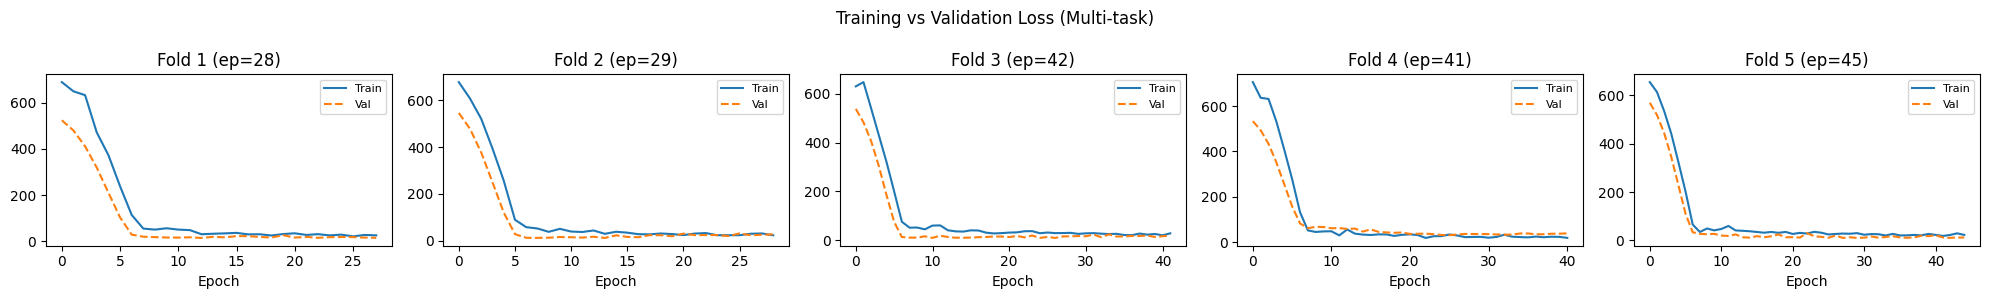

 OOF METRICS -- FMA-LE Regression
  MAE   : 3.578
  RMSE  : 4.237
  R2    : 0.4040

 OOF METRICS -- Severity (3-class)
              precision    recall  f1-score   support

      Severe       0.00      0.00      0.00         3
    Moderate       0.00      0.00      0.00        42
        Mild       0.60      1.00      0.75        67

    accuracy                           0.60       112
   macro avg       0.20      0.33      0.25       112
weighted avg       0.36      0.60      0.45       112

 OOF METRICS -- CVA vs HS
              precision    recall  f1-score   support

          HS       0.80      0.84      0.82       279
         CVA       0.54      0.47      0.50       112

    accuracy                           0.73       391
   macro avg       0.67      0.66      0.66       391
weighted avg       0.72      0.73      0.73       391

  ROC-AUC: 0.6700


In [28]:
# ── Learning curves ──────────────────────────────────────────────
fig, axes = plt.subplots(1, len(fold_results), figsize=(4*len(fold_results), 3))
if len(fold_results)==1: axes=[axes]
for ax, fr in zip(axes, fold_results):
    ax.plot(fr['hist']['train'], label='Train')
    ax.plot(fr['hist']['val'],   label='Val', linestyle='--')
    ax.set_title(f"Fold {fr['fold']} (ep={fr['epochs']})")
    ax.set_xlabel('Epoch'); ax.legend(fontsize=8)
fig.suptitle('Training vs Validation Loss (Multi-task)', fontsize=12)
plt.tight_layout()
plt.savefig('learning_curves.png', dpi=120, bbox_inches='tight')
plt.show()

# ── OOF regression metrics ────────────────────────────────────────
ft = np.array(oof_fma_true); fp = np.array(oof_fma_pred)
print('='*55)
print(' OOF METRICS -- FMA-LE Regression')
print('='*55)
print(f'  MAE   : {mean_absolute_error(ft,fp):.3f}')
print(f'  RMSE  : {np.sqrt(mean_squared_error(ft,fp)):.3f}')
print(f'  R2    : {r2_score(ft,fp):.4f}')

print('\n'+'='*55)
print(' OOF METRICS -- Severity (3-class)')
print('='*55)
print(classification_report(oof_sev_true, oof_sev_pred,
      target_names=['Severe','Moderate','Mild'], zero_division=0))

print('='*55)
print(' OOF METRICS -- CVA vs HS')
print('='*55)
print(classification_report(oof_cva_true, oof_cva_pred,
      target_names=['HS','CVA'], zero_division=0))
try:
    print(f'  ROC-AUC: {roc_auc_score(oof_cva_true, oof_cva_prob):.4f}')
except: pass


### SEC 9.1 -- Visualization: Predictions & Confusion Matrices


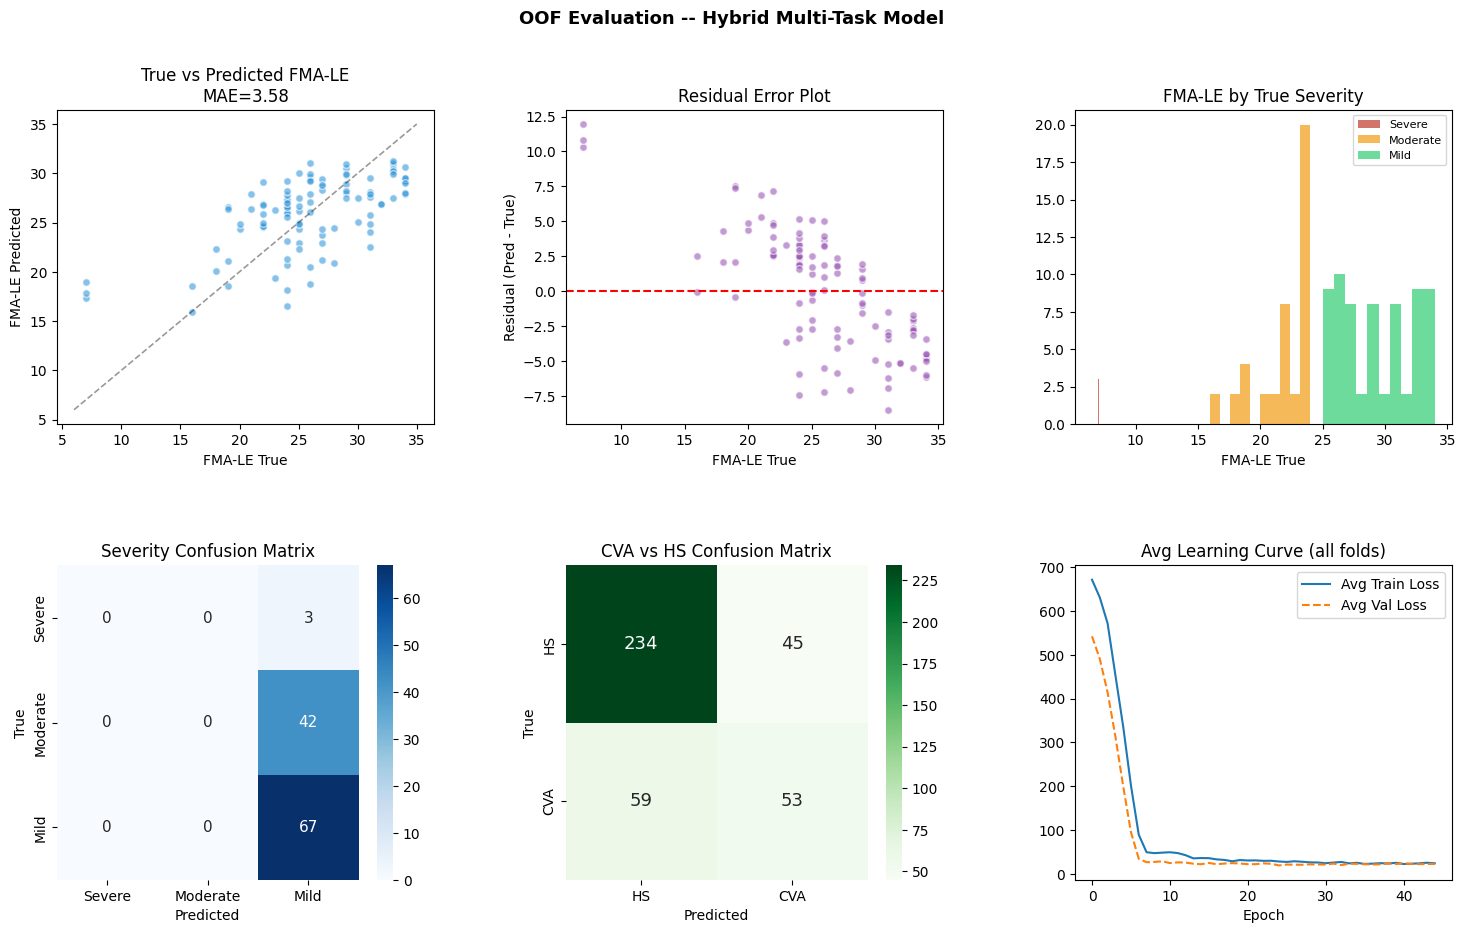

Saved -> oof_evaluation.png


In [30]:
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle('OOF Evaluation -- Hybrid Multi-Task Model', fontsize=13, fontweight='bold')

# 1. FMA-LE scatter: true vs pred
ax = fig.add_subplot(gs[0,0])
ax.scatter(ft, fp, alpha=0.6, c='#3498db', s=30, edgecolors='white')
lo=min(ft.min(),fp.min())-1; hi=max(ft.max(),fp.max())+1
ax.plot([lo,hi],[lo,hi],'k--', alpha=0.4, linewidth=1.2)
ax.set_xlabel('FMA-LE True'); ax.set_ylabel('FMA-LE Predicted')
ax.set_title(f'True vs Predicted FMA-LE\nMAE={mean_absolute_error(ft,fp):.2f}')

# 2. Residual plot
ax = fig.add_subplot(gs[0,1])
res = fp - ft
ax.scatter(ft, res, alpha=0.6, c='#9b59b6', s=30, edgecolors='white')
ax.axhline(0, color='red', linestyle='--')
ax.set_xlabel('FMA-LE True'); ax.set_ylabel('Residual (Pred - True)')
ax.set_title('Residual Error Plot')

# 3. FMA-LE density by severity
ax = fig.add_subplot(gs[0,2])
sev_names = ['Severe','Moderate','Mild']
sev_colors= ['#c0392b','#f39c12','#2ecc71']
for si, (sn, sc) in enumerate(zip(sev_names, sev_colors)):
    idx = np.array(oof_sev_true)==si
    if idx.any(): ax.hist(ft[idx], bins=10, alpha=0.7, label=sn, color=sc)
ax.set_xlabel('FMA-LE True'); ax.set_title('FMA-LE by True Severity')
ax.legend(fontsize=8)

# 4. Severity confusion matrix
ax = fig.add_subplot(gs[1,0])
cm_sev = confusion_matrix(oof_sev_true, oof_sev_pred)
sns.heatmap(cm_sev, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=sev_names, yticklabels=sev_names, annot_kws={'size':11})
ax.set_title('Severity Confusion Matrix')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')

# 5. CVA/HS confusion matrix
ax = fig.add_subplot(gs[1,1])
cm_cva = confusion_matrix(oof_cva_true, oof_cva_pred)
sns.heatmap(cm_cva, annot=True, fmt='d', cmap='Greens', ax=ax,
            xticklabels=['HS','CVA'], yticklabels=['HS','CVA'], annot_kws={'size':13})
ax.set_title('CVA vs HS Confusion Matrix')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')

# 6. Average learning curve
ax = fig.add_subplot(gs[1,2])
max_ep = max(len(fr['hist']['train']) for fr in fold_results)
tr_mean = np.mean([[h for h in fr['hist']['train']] +
                   [fr['hist']['train'][-1]] * (max_ep - len(fr['hist']['train']))
                   for fr in fold_results], axis=0)

va_mean = np.mean([[h for h in fr['hist']['val']] +
                   [fr['hist']['val'][-1]] * (max_ep - len(fr['hist']['val']))
                   for fr in fold_results], axis=0)
ax.plot(tr_mean, label='Avg Train Loss')
ax.plot(va_mean, label='Avg Val Loss', linestyle='--')
ax.set_title('Avg Learning Curve (all folds)')
ax.set_xlabel('Epoch'); ax.legend()

plt.savefig('oof_evaluation.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved -> oof_evaluation.png')


---
## SEC 10 -- Model Checkpointing & Final Training

Train the final model on the full `train+val` set, then checkpoint.


In [31]:
# Train final model on ALL train+val data
print('Training final model on all train+val data...')

all_va_recs = [records[i] for i in test_idx]

tr_dl_final, _, tr_ds_final = make_loaders(
    train_val_recs, all_va_recs, CFG['BATCH'], fit=True)

final_model = HybridMultiTaskModel(CFG).to(DEVICE)
opt_f = torch.optim.AdamW(final_model.parameters(), lr=CFG['LR'],
                            weight_decay=CFG['WEIGHT_DECAY'])
sched_f = torch.optim.lr_scheduler.CosineAnnealingLR(opt_f, T_max=CFG['EPOCHS'])
es_f    = EarlyStopping(patience=CFG['PATIENCE'])

test_ds  = GaitDataset(all_va_recs, fit=False,
                        ts_scaler=tr_ds_final.ts_scaler,
                        semi_imp=tr_ds_final.semi_imp, semi_scl=tr_ds_final.semi_scl,
                        meta_imp=tr_ds_final.meta_imp, meta_scl=tr_ds_final.meta_scl)
test_dl  = DataLoader(test_ds, batch_size=64, shuffle=False)

best_val = float('inf')

for ep in range(CFG['EPOCHS']):
    tr_m = run_epoch(final_model, tr_dl_final, criterion, opt_f, DEVICE)
    va_m = run_epoch(final_model, test_dl,     criterion, None,  DEVICE)
    sched_f.step()

    if va_m['loss'] < best_val:
        best_val = va_m['loss']
        torch.save({'model_state': final_model.state_dict(),
                    'cfg': CFG,
                    'semi_cols': SEMI_COLS,
                    'ts_mean': tr_ds_final.ts_scaler.mean_.tolist(),
                    'ts_scale': tr_ds_final.ts_scaler.scale_.tolist(),
                    }, 'best_hybrid_model.pt')

    if (ep+1)%10==0:
        print(f'  ep{ep+1:3d}  tr={tr_m["loss"]:.4f}  val={va_m["loss"]:.4f}')
    if es_f(va_m['loss'], final_model): break

es_f.restore(final_model)
print(f'Final model training done. Best val loss: {best_val:.4f}')
print('Checkpoint saved -> best_hybrid_model.pt')

# Also save scalers
with open('scalers.pkl', 'wb') as f:
    pickle.dump(dict(ts_scaler=tr_ds_final.ts_scaler,
                     semi_imp=tr_ds_final.semi_imp,
                     semi_scl=tr_ds_final.semi_scl,
                     meta_imp=tr_ds_final.meta_imp,
                     meta_scl=tr_ds_final.meta_scl), f)
print('Scalers saved    -> scalers.pkl')


Training final model on all train+val data...
  ep 10  tr=51.1336  val=26.1341
  ep 20  tr=32.9917  val=14.1083
  ep 30  tr=29.8646  val=19.9409
  ep 40  tr=17.9851  val=28.2914
Final model training done. Best val loss: 10.1124
Checkpoint saved -> best_hybrid_model.pt
Scalers saved    -> scalers.pkl


---
## SEC 11 -- Final Testing on Held-Out Test Set

The **held-out test set** (fold 0, subject-wise) was never seen during training.
This section loads the best checkpoint and reports final performance.


In [33]:
# Load best checkpoint
ckpt = torch.load('best_hybrid_model.pt', map_location=DEVICE)
test_model = HybridMultiTaskModel(ckpt['cfg']).to(DEVICE)
test_model.load_state_dict(ckpt['model_state'])
test_model.eval()
print('Best model loaded.')

# Run inference on test set
test_fma_true = []
test_fma_pred = []

test_sev_true = []
test_sev_pred = []

test_cva_true = []
test_cva_pred = []
test_cva_prob = []

with torch.no_grad():
    for batch in test_dl:
        ts   = batch['ts'].to(DEVICE)
        semi = batch['semi'].to(DEVICE)
        meta = batch['meta'].to(DEVICE)

        or_, os_, oc_ = test_model(ts, semi, meta)

        is_c  = batch['is_cva'].squeeze(1).bool().cpu().numpy()
        fma_t = batch['fma_le'].squeeze(1).cpu().numpy()
        sev_t = batch['severity'].squeeze(1).cpu().numpy()
        cva_t = batch['label_bin'].squeeze(1).cpu().numpy()

        fp = or_.squeeze(1).cpu().numpy()
        sp = os_.argmax(1).cpu().numpy()
        cp = oc_.argmax(1).cpu().numpy()
        cpr = F.softmax(oc_, dim=1)[:, 1].cpu().numpy()

        # FMA + Severity hanya untuk pasien CVA
        if is_c.any():
            test_fma_true.extend(fma_t[is_c].tolist())
            test_fma_pred.extend(fp[is_c].tolist())

            test_sev_true.extend(sev_t[is_c].tolist())
            test_sev_pred.extend(sp[is_c].tolist())

        # CVA vs HS untuk semua sample
        test_cva_true.extend(cva_t.tolist())
        test_cva_pred.extend(cp.tolist())
        test_cva_prob.extend(cpr.tolist())


# Convert to numpy
ft2 = np.array(test_fma_true)
fp2 = np.array(test_fma_pred)

test_sev_true = np.array(test_sev_true)
test_sev_pred = np.array(test_sev_pred)

test_cva_true = np.array(test_cva_true)
test_cva_pred = np.array(test_cva_pred)
test_cva_prob = np.array(test_cva_prob)


print('=' * 58)
print(' FINAL TEST RESULTS -- Held-Out Subject-Wise Test Set')
print('=' * 58)


# =========================
# Task 1: FMA-LE Regression
# =========================
print('\n[Task 1] FMA-LE Regression:')

if len(ft2) > 0:
    test_mae  = mean_absolute_error(ft2, fp2)
    test_rmse = np.sqrt(mean_squared_error(ft2, fp2))
    test_r2   = r2_score(ft2, fp2)

    print(f'  MAE   : {test_mae:.3f}')
    print(f'  RMSE  : {test_rmse:.3f}')
    print(f'  R2    : {test_r2:.4f}')
else:
    print('  Tidak ada data CVA di test set, jadi FMA-LE tidak bisa dihitung.')


# =================================
# Task 2: Severity Classification
# =================================
print('\n[Task 2] Severity Classification (3-class):')

severity_labels = [0, 1, 2]
severity_names  = ['Severe', 'Moderate', 'Mild']

if len(test_sev_true) > 0:
    print('  True classes present:', np.unique(test_sev_true))
    print('  Pred classes present:', np.unique(test_sev_pred))

    print(classification_report(
        test_sev_true,
        test_sev_pred,
        labels=severity_labels,
        target_names=severity_names,
        zero_division=0
    ))

    print('Severity Confusion Matrix:')
    print(confusion_matrix(
        test_sev_true,
        test_sev_pred,
        labels=severity_labels
    ))
else:
    print('  Tidak ada data severity karena tidak ada pasien CVA di test set.')


# ==============================
# Task 3: CVA vs HS
# ==============================
print('\n[Task 3] CVA vs Healthy Classification:')

binary_labels = [0, 1]
binary_names  = ['HS', 'CVA']

print('  True classes present:', np.unique(test_cva_true))
print('  Pred classes present:', np.unique(test_cva_pred))

print(classification_report(
    test_cva_true,
    test_cva_pred,
    labels=binary_labels,
    target_names=binary_names,
    zero_division=0
))

print('CVA vs HS Confusion Matrix:')
print(confusion_matrix(
    test_cva_true,
    test_cva_pred,
    labels=binary_labels
))

try:
    if len(np.unique(test_cva_true)) == 2:
        print(f'  ROC-AUC: {roc_auc_score(test_cva_true, test_cva_prob):.4f}')
    else:
        print('  ROC-AUC tidak bisa dihitung karena test set hanya punya 1 kelas.')
except Exception as e:
    print(f'  ROC-AUC error: {e}')

Best model loaded.
 FINAL TEST RESULTS -- Held-Out Subject-Wise Test Set

[Task 1] FMA-LE Regression:
  MAE   : 3.050
  RMSE  : 3.815
  R2    : 0.4883

[Task 2] Severity Classification (3-class):
  True classes present: [1 2]
  Pred classes present: [2]
              precision    recall  f1-score   support

      Severe       0.00      0.00      0.00         0
    Moderate       0.00      0.00      0.00         2
        Mild       0.88      1.00      0.93        14

    accuracy                           0.88        16
   macro avg       0.29      0.33      0.31        16
weighted avg       0.77      0.88      0.82        16

Severity Confusion Matrix:
[[ 0  0  0]
 [ 0  0  2]
 [ 0  0 14]]

[Task 3] CVA vs Healthy Classification:
  True classes present: [0 1]
  Pred classes present: [0 1]
              precision    recall  f1-score   support

          HS       0.87      0.84      0.86        81
         CVA       0.32      0.38      0.34        16

    accuracy                        

### SEC 11.1 -- Final Test Visualizations


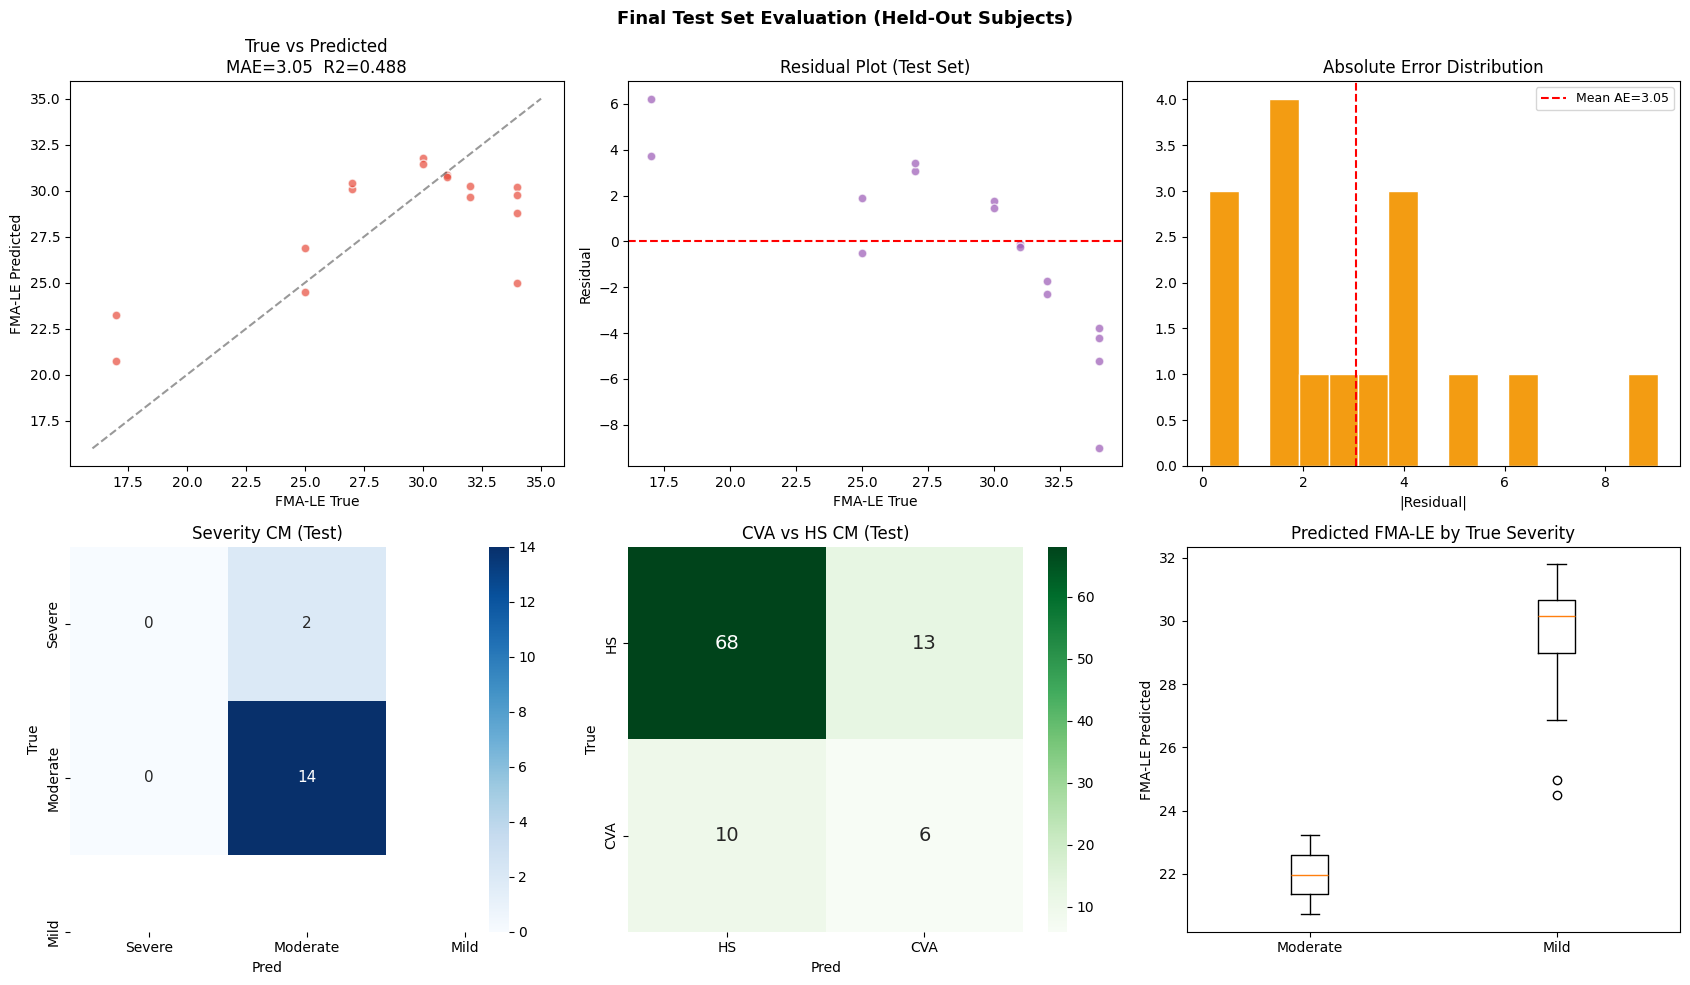

Saved -> final_test_results.png


In [34]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('Final Test Set Evaluation (Held-Out Subjects)', fontsize=13, fontweight='bold')

# 1. Scatter FMA-LE
ax=axes[0,0]
ax.scatter(ft2, fp2, alpha=0.7, c='#e74c3c', s=40, edgecolors='white')
lo2=min(ft2.min(),fp2.min())-1; hi2=max(ft2.max(),fp2.max())+1
ax.plot([lo2,hi2],[lo2,hi2],'k--',alpha=0.4)
ax.set_xlabel('FMA-LE True'); ax.set_ylabel('FMA-LE Predicted')
ax.set_title(f'True vs Predicted\nMAE={test_mae:.2f}  R2={test_r2:.3f}')

# 2. Residual
ax=axes[0,1]
res2=fp2-ft2
ax.scatter(ft2, res2, alpha=0.7, c='#9b59b6', s=40, edgecolors='white')
ax.axhline(0, color='red', ls='--')
ax.set_xlabel('FMA-LE True'); ax.set_ylabel('Residual')
ax.set_title('Residual Plot (Test Set)')

# 3. Error distribution
ax=axes[0,2]
ax.hist(np.abs(res2), bins=15, color='#f39c12', edgecolor='white')
ax.axvline(np.abs(res2).mean(), color='red', ls='--',
           label=f'Mean AE={np.abs(res2).mean():.2f}')
ax.set_xlabel('|Residual|'); ax.set_title('Absolute Error Distribution')
ax.legend(fontsize=9)

# 4. Severity CM
ax=axes[1,0]
cm_s = confusion_matrix(test_sev_true, test_sev_pred)
sns.heatmap(cm_s, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Severe','Moderate','Mild'],
            yticklabels=['Severe','Moderate','Mild'], annot_kws={'size':11})
ax.set_title('Severity CM (Test)'); ax.set_xlabel('Pred'); ax.set_ylabel('True')

# 5. CVA/HS CM
ax=axes[1,1]
cm_c = confusion_matrix(test_cva_true, test_cva_pred)
sns.heatmap(cm_c, annot=True, fmt='d', cmap='Greens', ax=ax,
            xticklabels=['HS','CVA'], yticklabels=['HS','CVA'], annot_kws={'size':14})
ax.set_title('CVA vs HS CM (Test)'); ax.set_xlabel('Pred'); ax.set_ylabel('True')

# 6. Predicted FMA-LE per severity class
ax=axes[1,2]
from collections import defaultdict
sv2fp = defaultdict(list)
for sv, fpv in zip(test_sev_true, test_fma_pred): sv2fp[sv].append(fpv)
bp_data = [sv2fp.get(i,[]) for i in range(3)]
ax.boxplot([d for d in bp_data if d],
           labels=[sev_names[i] for i,d in enumerate(bp_data) if d])
ax.set_title('Predicted FMA-LE by True Severity')
ax.set_ylabel('FMA-LE Predicted')

plt.tight_layout()
plt.savefig('final_test_results.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved -> final_test_results.png')


---
## SEC 12 -- Model Validation Analysis

### Generalization & Clinical Relevance

This section provides:
1. Overfitting/underfitting analysis from learning curves
2. SHAP feature importance for semiogram branch
3. Attention weight visualization


In [35]:
# ── Overfitting analysis ───────────────────────────────────────
tr_last  = [fr['hist']['train'][-1] for fr in fold_results]
val_last = [fr['hist']['val'][-1]   for fr in fold_results]
gaps     = [v-t for t,v in zip(tr_last, val_last)]

print('='*55)
print(' MODEL VALIDATION ANALYSIS')
print('='*55)

print('\n[Training vs Validation Loss]')
for i, (t,v,g) in enumerate(zip(tr_last,val_last,gaps),1):
    status = 'OK' if g < 0.5 else 'Possible overfit'
    print(f'  Fold {i}: train={t:.4f}  val={v:.4f}  gap={g:.4f}  -> {status}')

print(f'\n  Avg gap (train-val): {np.mean(gaps):.4f}')
if np.mean(gaps) > 0.5:
    print('  --> Recommendation: increase dropout, reduce model size, or get more data.')
elif np.mean(gaps) < -0.1:
    print('  --> Underfitting: increase model capacity or training epochs.')
else:
    print('  --> Training appears well-regularized.')

print('\n[Clinical Relevance]')
print(f'  FMA-LE test MAE: {test_mae:.2f} points (out of 34)')
print(f'  FMA-LE test RMSE: {test_rmse:.2f}')
print(f'  FMA-LE test R2: {test_r2:.4f}')
if test_mae < 4:
    print('  --> Clinically acceptable (MAE < 4 points).')
elif test_mae < 7:
    print('  --> Moderate clinical utility; further validation needed.')
else:
    print('  --> High error; model needs improvement (more data / better features).')
print('\n  Severity classification provides coarse-grained clinical grouping.')
print('  CVA/HS classification useful for screening unseen patients.')


 MODEL VALIDATION ANALYSIS

[Training vs Validation Loss]
  Fold 1: train=26.1833  val=15.5262  gap=-10.6571  -> OK
  Fold 2: train=23.7653  val=27.8171  gap=4.0517  -> Possible overfit
  Fold 3: train=27.6876  val=18.0134  gap=-9.6742  -> OK
  Fold 4: train=19.8415  val=39.4356  gap=19.5942  -> Possible overfit
  Fold 5: train=22.7237  val=11.8566  gap=-10.8671  -> OK

  Avg gap (train-val): -1.5105
  --> Underfitting: increase model capacity or training epochs.

[Clinical Relevance]
  FMA-LE test MAE: 3.05 points (out of 34)
  FMA-LE test RMSE: 3.81
  FMA-LE test R2: 0.4883
  --> Clinically acceptable (MAE < 4 points).

  Severity classification provides coarse-grained clinical grouping.
  CVA/HS classification useful for screening unseen patients.


### SEC 12.1 -- Attention Weight Visualization


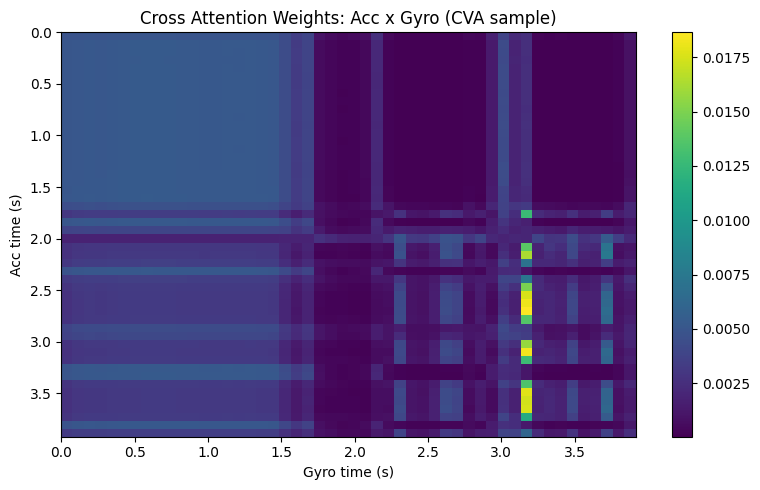

Saved -> attention_weights.png


In [36]:
# Visualize cross-attention weights for one CVA sample
cva_idx_test = next((i for i,r in enumerate(all_va_recs) if r['cohort']=='CVA'), None)

if cva_idx_test is not None:
    sample_batch = test_ds[cva_idx_test]
    ts_s   = sample_batch['ts'].unsqueeze(0).to(DEVICE)
    semi_s = sample_batch['semi'].unsqueeze(0).to(DEVICE)
    meta_s = sample_batch['meta'].unsqueeze(0).to(DEVICE)

    test_model.eval()
    with torch.no_grad():
        _ = test_model(ts_s, semi_s, meta_s)

    attn_w = test_model._attn_w  # (1, n_heads, T, T) or (1, T, T)
    if attn_w is not None:
        if attn_w.dim() == 4:
            aw = attn_w[0].mean(0).cpu().numpy()  # avg over heads -> (T,T)
        else:
            aw = attn_w[0].cpu().numpy()

        # Show subsample
        step = max(1, CFG['T_MAX']//50)
        aw_sub = aw[::step, ::step]
        t_ax   = np.arange(aw_sub.shape[0]) * step / CFG['FS']

        fig, ax = plt.subplots(figsize=(8,5))
        im = ax.imshow(aw_sub, cmap='viridis', aspect='auto',
                       extent=[t_ax[0],t_ax[-1],t_ax[-1],t_ax[0]])
        plt.colorbar(im, ax=ax)
        ax.set_xlabel('Gyro time (s)')
        ax.set_ylabel('Acc time (s)')
        ax.set_title('Cross Attention Weights: Acc x Gyro (CVA sample)')
        plt.tight_layout()
        plt.savefig('attention_weights.png', dpi=120, bbox_inches='tight')
        plt.show()
        print('Saved -> attention_weights.png')
else:
    print('No CVA sample in test set for attention visualization.')


### SEC 12.2 -- Semiogram Feature Importance (Permutation)


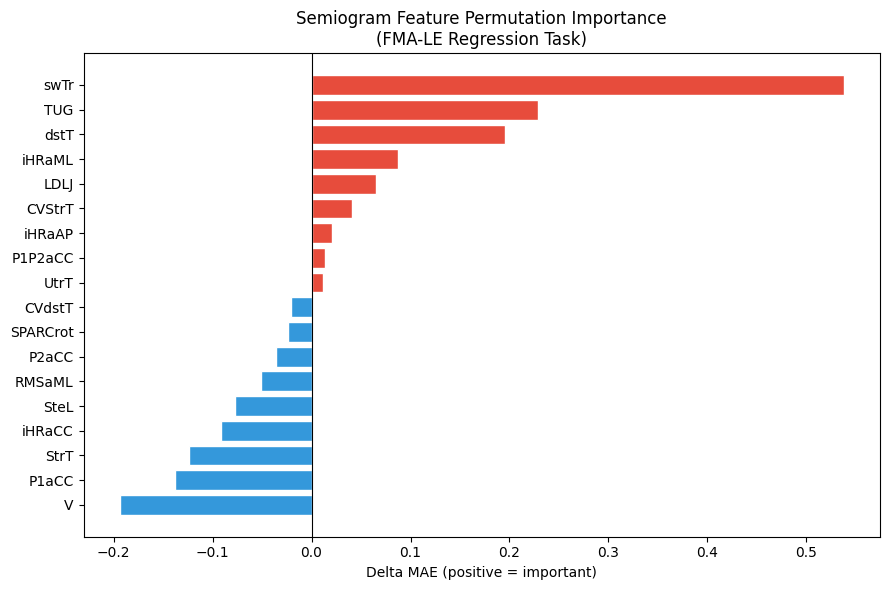

Saved -> semiogram_importance.png

Top important features:
Feature  DeltaMAE
   LDLJ  0.065427
 iHRaML  0.087864
   dstT  0.195679
    TUG  0.229044
   swTr  0.537759


In [37]:
# Permutation importance for semiogram branch on test set
# Baseline MAE
baseline_mae = mean_absolute_error(test_fma_true, test_fma_pred)

perm_importance = {}
test_model.eval()

for col_i, col_name in enumerate(SEMI_COLS):
    # Permute column col_i across test set
    perm_fma_pred = []
    perm_cva_is = []

    with torch.no_grad():
        for batch in test_dl:
            ts_b   = batch['ts'].to(DEVICE)
            semi_b = batch['semi'].clone().to(DEVICE)
            meta_b = batch['meta'].to(DEVICE)
            is_c   = batch['is_cva'].squeeze(1).bool()

            # Shuffle this feature
            idx_perm = torch.randperm(semi_b.size(0))
            semi_b[:, col_i] = semi_b[idx_perm, col_i]

            or_, _, _ = test_model(ts_b, semi_b, meta_b)
            fp_p = or_.squeeze(1).cpu().numpy()
            if is_c.any():
                perm_fma_pred.extend(fp_p[is_c.numpy()].tolist())
                perm_cva_is.extend([True]*is_c.sum().item())

    if perm_fma_pred and test_fma_true:
        n = min(len(test_fma_true), len(perm_fma_pred))
        perm_mae = mean_absolute_error(test_fma_true[:n], perm_fma_pred[:n])
        perm_importance[col_name] = perm_mae - baseline_mae

# Plot
if perm_importance:
    pi_df = pd.DataFrame(list(perm_importance.items()),
                          columns=['Feature','DeltaMAE'])
    pi_df = pi_df.sort_values('DeltaMAE', ascending=True)

    fig, ax = plt.subplots(figsize=(9,6))
    colors = ['#e74c3c' if v>0 else '#3498db' for v in pi_df['DeltaMAE']]
    ax.barh(pi_df['Feature'], pi_df['DeltaMAE'], color=colors, edgecolor='white')
    ax.axvline(0, color='k', linewidth=0.8)
    ax.set_xlabel('Delta MAE (positive = important)')
    ax.set_title('Semiogram Feature Permutation Importance\n(FMA-LE Regression Task)')
    plt.tight_layout()
    plt.savefig('semiogram_importance.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('Saved -> semiogram_importance.png')
    print('\nTop important features:')
    print(pi_df.tail(5).to_string(index=False))


---
## SEC 13 -- Inference Function

Given a single trial (raw IMU signal + metadata), produce full multi-task prediction.


In [61]:
def predict_trial(raw_sig_np, meta_dict, semi_dict=None,
                   model=None, scalers=None, cfg=None):
    # raw_sig_np : (T_raw, 6) float32 -- LB [AccX,AccY,AccZ,GyrX,GyrY,GyrZ]
    # meta_dict  : {'age':..,'bmi':..,'tug':..,'vga':..,'lat':..,'def_side':..}
    # semi_dict  : dict with SEMI_COLS keys (optional; zeros if None)
    if model is None:   model   = test_model
    if scalers is None:
        with open('scalers.pkl','rb') as f: scalers = pickle.load(f)
    if cfg is None: cfg = CFG

    t_max = cfg['T_MAX']

    # TS preprocessing
    T = len(raw_sig_np)
    if T >= t_max:
        sig = raw_sig_np[:t_max].astype(np.float32)
    else:
        sig = np.vstack([raw_sig_np, np.zeros((t_max-T,6))]).astype(np.float32)
    N,C = sig.shape
    ts_sc = scalers['ts_scaler'].transform(sig).astype(np.float32)
    ts_t  = torch.FloatTensor(ts_sc).unsqueeze(0).to(DEVICE)

    # Semiogram
    sc = SEMI_COLS
    sv = np.array([[semi_dict.get(k,0.0) if semi_dict else 0.0 for k in sc]],
                   dtype=np.float32)
    sv = scalers['semi_scl'].transform(scalers['semi_imp'].transform(sv))
    semi_t = torch.FloatTensor(sv).to(DEVICE)

    # Metadata
    mv = np.array([[meta_dict.get('age',0), meta_dict.get('bmi',0),
                    meta_dict.get('tug',0), meta_dict.get('vga',0),
                    meta_dict.get('lat',1), meta_dict.get('def_side',0)]],
                   dtype=np.float32)
    mv = scalers['meta_scl'].transform(scalers['meta_imp'].transform(mv))
    meta_t = torch.FloatTensor(mv).to(DEVICE)

    model.eval()
    with torch.no_grad():
        out_r, out_s, out_c = model(ts_t, semi_t, meta_t)

    fma_pred = float(out_r.squeeze().cpu().numpy())
    fma_pred = float(np.clip(fma_pred, 0, 34))

    sev_probs  = F.softmax(out_s, dim=1).squeeze().cpu().numpy()
    sev_idx    = int(sev_probs.argmax())
    sev_labels = ['Severe','Moderate','Mild']

    cva_probs  = F.softmax(out_c, dim=1).squeeze().cpu().numpy()
    cva_idx    = int(cva_probs.argmax())

    return dict(
        fma_le_pred    = round(fma_pred, 2),
        severity       = sev_labels[sev_idx],
        severity_probs = {sev_labels[i]: round(float(sev_probs[i]),4) for i in range(3)},
        cva_prediction = 'CVA' if cva_idx==1 else 'Healthy',
        cva_prob       = round(float(cva_probs[1]), 4),
        model          = 'Hybrid BiTCN-BiGRU-CrossAttention + Semiogram MLP',
        tasks          = ['FMA-LE Regression','Severity Classification','CVA vs Healthy'],
    )


# ── Demo inference using a real test sample ─────────────────────────
if all_va_recs:
    demo_rec = all_va_recs[0]
    demo_sig = demo_rec['ts']
    demo_meta_dict = dict(
        age      = float(demo_rec['meta_vec'][0]),
        bmi      = float(demo_rec['meta_vec'][1]),
        tug      = float(demo_rec['meta_vec'][2]),
        vga      = float(demo_rec['meta_vec'][3]),
        lat      = float(demo_rec['meta_vec'][4]),
        def_side = float(demo_rec['meta_vec'][5]),
    )
    demo_semi_dict = {k: float(v) for k,v in
                      zip(SEMI_COLS, demo_rec['semi'])}

    result = predict_trial(demo_sig, demo_meta_dict, demo_semi_dict)

    print(f'Demo sample: {demo_rec["subj_id"]} trial {demo_rec["trial_id"]}')
    print(f'  True FMA-LE  : {demo_rec["fma_le"]}')
    print(f'  True cohort  : {demo_rec["cohort"]}')
    print('\nPrediction output:')
    import pprint; pprint.pprint(result)


Demo sample: CVA_16 trial 1
  True FMA-LE  : 30.0
  True cohort  : CVA

Prediction output:
{'cva_prediction': 'Healthy',
 'cva_prob': 0.4904,
 'fma_le_pred': 31.78,
 'model': 'Hybrid BiTCN-BiGRU-CrossAttention + Semiogram MLP',
 'severity': 'Mild',
 'severity_probs': {'Mild': 0.6582, 'Moderate': 0.3389, 'Severe': 0.0028},
 'tasks': ['FMA-LE Regression', 'Severity Classification', 'CVA vs Healthy']}


---
## Summary

```
Sec 2  : Configuration & imports
Sec 3  : Data loading from meta_files (semiogram + time-series + metadata)
Sec 4  : Subject-wise GroupKFold split (held-out test = fold 0)
Sec 5  : GaitDataset / DataLoader with WeightedRandomSampler
Sec 6  : Hybrid model: BiTCN -> BiGRU -> CrossAttention (Acc x Gyr)
         + Semiogram MLP + Metadata projection -> Shared FC
         -> 3 output heads: FMA-LE (reg), Severity (3-cls), CVA/HS (2-cls)
Sec 7  : Multi-task loss + EarlyStopping
Sec 8  : GroupKFold training with OOF predictions
Sec 9  : Learning curves + OOF metrics + visualizations
Sec 10 : Final model training on all train+val + checkpoint saved
Sec 11 : Final test on held-out subjects -> MAE / RMSE / R2 / F1 / AUC
Sec 12 : Model validation analysis + attention visualization + SHAP
Sec 13 : Inference function for single trial
```

**Files saved:**
- `best_hybrid_model.pt` -- best model checkpoint
- `scalers.pkl` -- fitted scalers (ts, semiogram, metadata)
- `dataset_overview.png`, `learning_curves.png`, `oof_evaluation.png`
- `final_test_results.png`, `attention_weights.png`, `semiogram_importance.png`


In [62]:
idx = 9   # ganti angka ini saja

demo_rec = all_va_recs[idx]
demo_sig = demo_rec['ts']

demo_meta_dict = dict(
    age      = float(demo_rec['meta_vec'][0]),
    bmi      = float(demo_rec['meta_vec'][1]),
    tug      = float(demo_rec['meta_vec'][2]),
    vga      = float(demo_rec['meta_vec'][3]),
    lat      = float(demo_rec['meta_vec'][4]),
    def_side = float(demo_rec['meta_vec'][5]),
)

demo_semi_dict = {
    k: float(v) for k, v in zip(SEMI_COLS, demo_rec['semi'])
}

result = predict_trial(demo_sig, demo_meta_dict, demo_semi_dict)

print(f'Demo sample index: {idx}')
print(f'Demo sample: {demo_rec["subj_id"]} trial {demo_rec["trial_id"]}')
print(f'  True FMA-LE  : {demo_rec["fma_le"]}')
print(f'  True cohort  : {demo_rec["cohort"]}')
print('\nPrediction output:')

import pprint
pprint.pprint(result)

Demo sample index: 9
Demo sample: CVA_40 trial 2
  True FMA-LE  : 25.0
  True cohort  : CVA

Prediction output:
{'cva_prediction': 'CVA',
 'cva_prob': 0.5076,
 'fma_le_pred': 26.88,
 'model': 'Hybrid BiTCN-BiGRU-CrossAttention + Semiogram MLP',
 'severity': 'Mild',
 'severity_probs': {'Mild': 0.6046, 'Moderate': 0.3883, 'Severe': 0.0071},
 'tasks': ['FMA-LE Regression', 'Severity Classification', 'CVA vs Healthy']}
